In [23]:
import pandas as pd # Import da biblioteca para ler o dataset (CSV)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('/content/churn_saas.csv') # Para ler o CSV
df.head() # Comando para ver as 5 primeiras linhas, para ter noção dos dados.

,cliente_id,tenure_meses,plano,mensalidade,contrato,usuarios_ativos,logins_30d,features_usadas,tickets_suporte,nps,atraso_pagamento_dias,desconto_ativo,integracoes_ativas,churn
0,C00000,17,Enterprise,494.51,Mensal,106,10,2,3,7,5.0,0,5,0
1,C00001,23,Basic,45.85,Mensal,1,11,2,2,8,1.3,1,2,0
2,C00002,15,Basic,48.49,Anual,1,16,5,6,7,2.4,1,5,0
3,C00003,13,Basic,49.89,Anual,3,12,11,0,5,0.3,0,6,0
4,C00004,25,Basic,48.80,Mensal,2,8,5,0,5,4.5,0,7,0


In [11]:
df.shape # comando para ver quantidade de linhas e colunas

(3000, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cliente_id             3000 non-null   object 
 1   tenure_meses           3000 non-null   int64  
 2   plano                  3000 non-null   object 
 3   mensalidade            3000 non-null   float64
 4   contrato               3000 non-null   object 
 5   usuarios_ativos        3000 non-null   int64  
 6   logins_30d             3000 non-null   int64  
 7   features_usadas        3000 non-null   int64  
 8   tickets_suporte        3000 non-null   int64  
 9   nps                    3000 non-null   int64  
 10  atraso_pagamento_dias  3000 non-null   float64
 11  desconto_ativo         3000 non-null   int64  
 12  integracoes_ativas     3000 non-null   int64  
 13  churn                  3000 non-null   int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 328.3+ 

In [13]:
df.isnull().sum() # Comando para identificar quantos valores Null`s existem naquele dataset

,0
cliente_id,0
tenure_meses,0
plano,0
mensalidade,0
contrato,0
usuarios_ativos,0
logins_30d,0
features_usadas,0
tickets_suporte,0
nps,0


In [22]:
valor = df['churn'].value_counts(normalize=True) * 100 # Forma para pegar qual a % de churn nesse dataset no caso sem churns são 81% da base e churns são 18%
print(valor.round(2))

churn
0    81.73
1    18.27
Name: proportion, dtype: float64


<Axes: xlabel='contrato'>

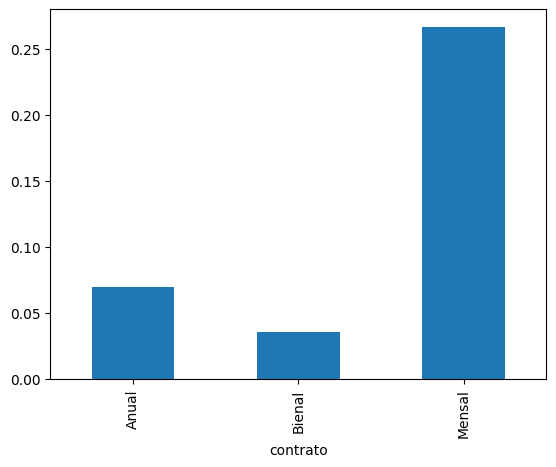

In [29]:
df.groupby('contrato')['churn'].mean().plot(kind='bar') #Gráfico para analisar taxa de churn por contratos

<Axes: xlabel='plano'>

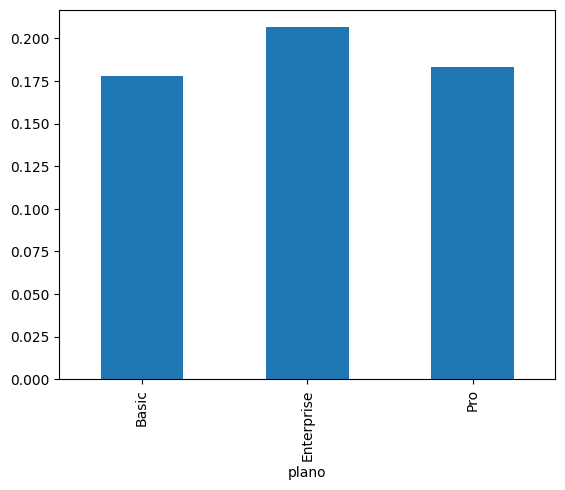

In [32]:
df.groupby('plano')['churn'].mean().plot(kind='bar') #Gráfico para analisar taxa de churn por planos

<Axes: xlabel='desconto_ativo'>

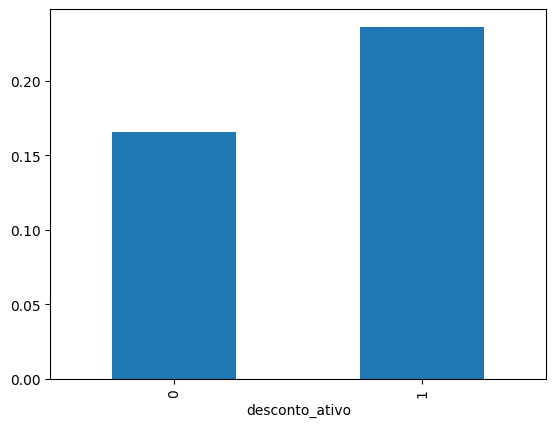

In [34]:
df.groupby('desconto_ativo')['churn'].mean().plot(kind='bar') # Gráfico para analisar taxa de churn por desconto

In [35]:
df.describe() # Comando para ter noção dos dados em gerais

,tenure_meses,mensalidade,usuarios_ativos,logins_30d,features_usadas,tickets_suporte,nps,atraso_pagamento_dias,desconto_ativo,integracoes_ativas,churn
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,16.036000,130.499573,15.274000,10.899667,10.016000,2.0030,5.002000,2.008300,0.241333,3.525000,0.182667
std,11.181192,133.088229,26.268821,4.848240,5.476532,1.4256,3.149704,1.928895,0.427963,2.307918,0.386457
min,1.000000,41.000000,1.000000,0.000000,1.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,48.620000,2.000000,7.000000,5.000000,1.0000,2.000000,0.600000,0.000000,2.000000,0.000000
50%,14.000000,52.500000,4.000000,10.000000,10.000000,2.0000,5.000000,1.400000,0.000000,4.000000,0.000000
75%,21.000000,150.152500,16.000000,14.000000,15.000000,3.0000,8.000000,2.800000,0.000000,6.000000,0.000000
max,72.000000,571.330000,163.000000,30.000000,19.000000,8.0000,10.000000,16.200000,1.000000,7.000000,1.000000


In [37]:
df.groupby('churn')[['logins_30d', 'nps', 'tickets_suporte', 'tenure_meses', 'atraso_pagamento_dias']].mean().round(2) #Comando para ter noção dos churns 1(deu churn) e 0 (não deu churn)

,logins_30d,nps,tickets_suporte,tenure_meses,atraso_pagamento_dias
churn,,,,,
0,11.47,5.20,1.93,16.43,1.95
1,8.34,4.11,2.34,14.29,2.25


In [38]:
df.select_dtypes(include='number').corr() # Correlação entre variáveis numéricas (-1 a +1)

,tenure_meses,mensalidade,usuarios_ativos,logins_30d,features_usadas,tickets_suporte,nps,atraso_pagamento_dias,desconto_ativo,integracoes_ativas,churn
tenure_meses,1.000000,0.008113,0.001306,0.001026,-0.015093,0.021561,-0.005399,-0.014743,0.019089,0.013106,-0.073674
mensalidade,0.008113,1.000000,0.896209,0.021487,0.038442,-0.006122,-0.006693,0.000743,0.014472,0.028108,0.020916
usuarios_ativos,0.001306,0.896209,1.000000,0.021397,0.030212,-0.003040,0.007356,0.005564,0.021226,0.018405,0.033301
logins_30d,0.001026,0.021487,0.021397,1.000000,0.006302,0.015337,0.033204,-0.011068,0.006853,0.005931,-0.250046
features_usadas,-0.015093,0.038442,0.030212,0.006302,1.000000,-0.005473,-0.003733,0.007150,0.004896,-0.006917,-0.094020
tickets_suporte,0.021561,-0.006122,-0.003040,0.015337,-0.005473,1.000000,0.023985,0.019744,0.002092,-0.010005,0.112789
nps,-0.005399,-0.006693,0.007356,0.033204,-0.003733,0.023985,1.000000,-0.007044,-0.009016,0.021277,-0.133434
atraso_pagamento_dias,-0.014743,0.000743,0.005564,-0.011068,0.007150,0.019744,-0.007044,1.000000,-0.047021,-0.018783,0.058711
desconto_ativo,0.019089,0.014472,0.021226,0.006853,0.004896,0.002092,-0.009016,-0.047021,1.000000,-0.013538,0.078123
integracoes_ativas,0.013106,0.028108,0.018405,0.005931,-0.006917,-0.010005,0.021277,-0.018783,-0.013538,1.000000,-0.093351


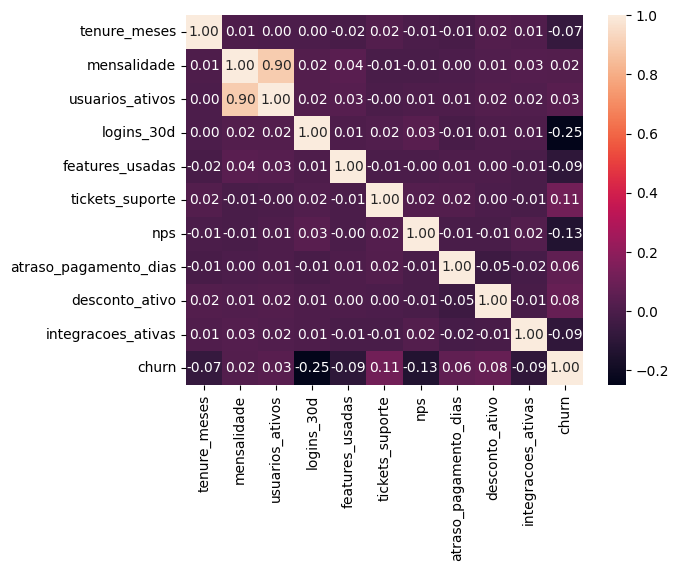

In [39]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f') #Comando para entender a correlação dos campos entre eles mas através de um mapa de calor
plt.show()

In [50]:
df_ml = df.drop(columns=['cliente_id'])# Remover coluna de identificador (sem poder preditivo)
df_ml = pd.get_dummies(df_ml, columns=['plano', 'contrato'], dtype=int) # Mesmo comando de antes porém faltou o dtype para int, para deixar as colunas como 1 e 0 para não interferir no treinamento do modelo
df_ml.head()

,tenure_meses,mensalidade,usuarios_ativos,logins_30d,features_usadas,tickets_suporte,nps,atraso_pagamento_dias,desconto_ativo,integracoes_ativas,churn,plano_Basic,plano_Enterprise,plano_Pro,contrato_Anual,contrato_Bienal,contrato_Mensal
0,17,494.51,106,10,2,3,7,5.0,0,5,0,0,1,0,0,0,1
1,23,45.85,1,11,2,2,8,1.3,1,2,0,1,0,0,0,0,1
2,15,48.49,1,16,5,6,7,2.4,1,5,0,1,0,0,1,0,0
3,13,49.89,3,12,11,0,5,0.3,0,6,0,1,0,0,1,0,0
4,25,48.80,2,8,5,0,5,4.5,0,7,0,1,0,0,0,0,1


In [51]:
X = df_ml.drop(columns=['churn'])
y = df_ml['churn']
print('X:', X.shape)
print('y:', y.shape)

X: (3000, 16)
y: (3000,)


In [52]:
from sklearn.model_selection import train_test_split # Import do modelo de treino

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
# Separando 75% treino e 25% teste
# random_state=42: fixa a aleatoriedade para resultados reproduzíveis
# stratify=y: mantém a mesma proporção de churn no treino e no teste

In [53]:
print('Treino:', X_train.shape)
print('Teste:', X_test.shape)
print('Churn treino:', y_train.mean().round(4))
print('Churn teste:', y_test.mean().round(4))

Treino: (2250, 16)
Teste: (750, 16)
Churn treino: 0.1827
Churn teste: 0.1827


In [55]:
from sklearn.preprocessing import StandardScaler # Import do StandardScaler para normalizar todas as features para a mesma escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit e transform dos dados de treino
X_test_scaled = scaler.transform(X_test) # Transform dos dados que serão testados (dados reais)

In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)

plt.bar(range(1, 17), pca_full.explained_variance_ratio_)
plt.xlabel('Componente')
plt.ylabel('Variância explicada')
plt.title('Scree Plot - Quanto cada componente explica')
plt.show()

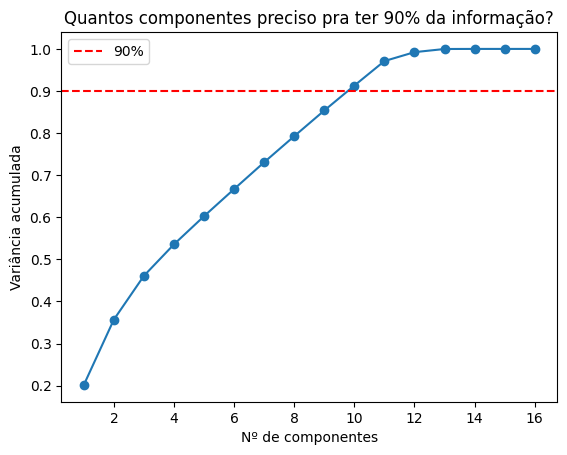

In [58]:
cum = np.cumsum(pca_full.explained_variance_ratio_) # Gráfico gerado para explicar quantos componentes precisamos para pegar a maior parte dos dados

plt.plot(range(1, 17), cum, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90%')
plt.xlabel('Nº de componentes')
plt.ylabel('Variância acumulada')
plt.title('Quantos componentes preciso pra ter 90% da informação?')
plt.legend()
plt.show()

In [59]:
print('Variância acumulada por componente:')
for i, v in enumerate(cum):
    print(f'  {i+1} componentes: {v:.1%}') # PCA: verificando quantos componentes são necessários pra manter 90% da variância (informação) dos dados

Variância acumulada por componente:
  1 componentes: 20.2%
  2 componentes: 35.7%
  3 componentes: 46.1%
  4 componentes: 53.6%
  5 componentes: 60.3%
  6 componentes: 66.7%
  7 componentes: 73.1%
  8 componentes: 79.3%
  9 componentes: 85.4%
  10 componentes: 91.3%
  11 componentes: 97.1%
  12 componentes: 99.2%
  13 componentes: 100.0%
  14 componentes: 100.0%
  15 componentes: 100.0%
  16 componentes: 100.0%


In [60]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Antes:', X_train_scaled.shape)
print('Depois:', X_train_pca.shape)

Antes: (2250, 16)
Depois: (2250, 10)


# Treinamento
Treinaremos 4 modelos para verificar qual modelo é mais eficiente nesse caso.

In [62]:
from sklearn.linear_model import LogisticRegression # Modelo de regressão logistica.

modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42) # Máximo de iterações 1000, peso da classe balanced por conta dos churn para equilibrar igualmente, random state iguais os casos de teste
modelo_lr.fit(X_train_pca, y_train)

print('Treino pronto!')
print('Score no treino:', round(modelo_lr.score(X_train_pca, y_train), 4))
print('Score no teste:', round(modelo_lr.score(X_test_pca, y_test), 4))

Treino pronto!
Score no treino: 0.6498
Score no teste: 0.6933


Tivemos um retorno de 0.64 de treino e 0.69 no teste.

In [63]:
from sklearn.tree import DecisionTreeClassifier # Modelo que treina por classificação de arvore

modelo_dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42) # Max depth quando fundo raiz vai, mesmo caso do peso da classe e random state
modelo_dt.fit(X_train_pca, y_train)

print('Árvore de Decisão')
print('Score treino:', round(modelo_dt.score(X_train_pca, y_train), 4))
print('Score teste:', round(modelo_dt.score(X_test_pca, y_test), 4))

Árvore de Decisão
Score treino: 0.74
Score teste: 0.688


Tivemos um retorno melhor comparado ao modelo anterior

In [64]:
from sklearn.ensemble import RandomForestClassifier # Modelo Random forest

modelo_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train_pca, y_train)

print('Random Forest')
print('Score treino:', round(modelo_rf.score(X_train_pca, y_train), 4))
print('Score teste:', round(modelo_rf.score(X_test_pca, y_test), 4))

Random Forest
Score treino: 1.0
Score teste: 0.82


Modelo Random forest teve 100% de acerto, isso parece bom mas é apenas um caso de overfitting onde o modelo ele decorou as respostas.

In [65]:
from sklearn.neighbors import KNeighborsClassifier # Modelo KNN

modelo_knn = KNeighborsClassifier(n_neighbors=15)
modelo_knn.fit(X_train_pca, y_train)

print('KNN')
print('Score treino:', round(modelo_knn.score(X_train_pca, y_train), 4))
print('Score teste:', round(modelo_knn.score(X_test_pca, y_test), 4))

KNN
Score treino: 0.8302
Score teste: 0.812


Parece bom olhando acurácia, mas será que é mesmo? Vamos verificar com métricas mais detalhadas. 👀

# Vendo as métricas 👀

Agora vamos ver as métricas de cada modelo

In [66]:
from sklearn.metrics import classification_report

y_pred_lr = modelo_lr.predict(X_test_pca)
print(classification_report(y_test, y_pred_lr, target_names=['Ativo', 'Churn']))

              precision    recall  f1-score   support

       Ativo       0.94      0.67      0.78       613
       Churn       0.35      0.80      0.49       137

    accuracy                           0.69       750
   macro avg       0.64      0.73      0.63       750
weighted avg       0.83      0.69      0.73       750



In [67]:
y_pred_dt = modelo_dt.predict(X_test_pca)
print('=== Árvore de Decisão ===')
print(classification_report(y_test, y_pred_dt, target_names=['Ativo', 'Churn']))

y_pred_rf = modelo_rf.predict(X_test_pca)
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Ativo', 'Churn']))

y_pred_knn = modelo_knn.predict(X_test_pca)
print('=== KNN ===')
print(classification_report(y_test, y_pred_knn, target_names=['Ativo', 'Churn']))

=== Árvore de Decisão ===
              precision    recall  f1-score   support

       Ativo       0.89      0.70      0.79       613
       Churn       0.32      0.61      0.42       137

    accuracy                           0.69       750
   macro avg       0.60      0.66      0.60       750
weighted avg       0.79      0.69      0.72       750

=== Random Forest ===
              precision    recall  f1-score   support

       Ativo       0.83      0.98      0.90       613
       Churn       0.55      0.09      0.15       137

    accuracy                           0.82       750
   macro avg       0.69      0.54      0.53       750
weighted avg       0.78      0.82      0.76       750

=== KNN ===
              precision    recall  f1-score   support

       Ativo       0.83      0.98      0.89       613
       Churn       0.42      0.07      0.12       137

    accuracy                           0.81       750
   macro avg       0.62      0.53      0.51       750
weighted avg  

Olhando as métricas podemos ver alguns pontos e análisar qual modelo é relacionado ao nosso caso, exemplo em churn
- Precision é, todas as respostas do modelo que disse que iria dar churn, quantos % ele acertou desses cara
- Recall de todos os clientes que realmente churnaram, o modelo pegou essa %.  Ele deixou escapar só % dos churners.

Assim podemos comparar todos os modelos e temos o seguinte caso:

- Mesmo o KNN e o Random Forest tendo acurácia alta (81% e 82%), eles não são os melhores modelos para prever churn. O motivo: o recall deles é muito baixo (0.07 e 0.09). Isso significa que de todos os clientes que realmente churnaram, eles detectaram menos de 10%. Na prática, esses modelos estão quase sempre chutando "não churn" e acertam bastante simplesmente porque 82% da base é ativa. A acurácia alta é uma ilusão.
- A Árvore de Decisão teve um desempenho intermediário (recall de 0.61), mas ainda deixou escapar quase 40% dos churners.
- A Regressão Logística foi o melhor modelo para o nosso caso, com recall de 0.80, detectou 80% dos clientes que realmente churnaram. A precision é baixa (0.35), o que significa que haverá falsos alarmes, mas em churn é preferível ligar pra um cliente que ia ficar do que perder um que ia sair sem saber.

In [68]:
modelo_lr_full = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr_full.fit(X_train_scaled, y_train)

y_pred_full = modelo_lr_full.predict(X_test_scaled)
print(classification_report(y_test, y_pred_full, target_names=['Ativo', 'Churn']))

              precision    recall  f1-score   support

       Ativo       0.93      0.69      0.80       613
       Churn       0.36      0.77      0.49       137

    accuracy                           0.71       750
   macro avg       0.65      0.73      0.64       750
weighted avg       0.83      0.71      0.74       750



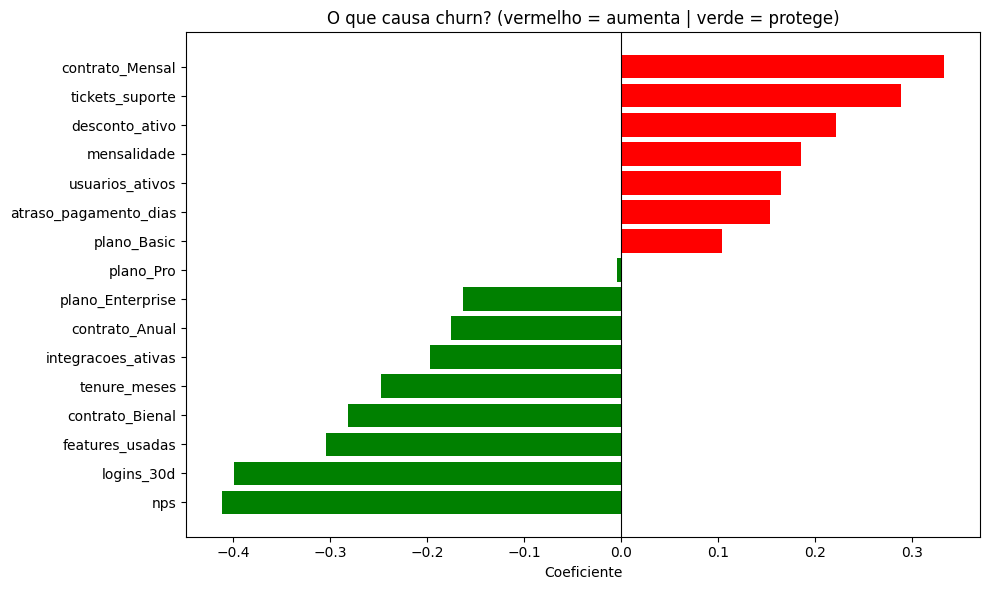

In [69]:
coefs = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': modelo_lr_full.coef_[0]
}).sort_values('coeficiente')

plt.figure(figsize=(10, 6))
cores = ['green' if c < 0 else 'red' for c in coefs['coeficiente']]
plt.barh(coefs['feature'], coefs['coeficiente'], color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('O que causa churn? (vermelho = aumenta | verde = protege)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()